In [2]:
import pandas
import numpy as np
import matplotlib.pyplot as plot
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

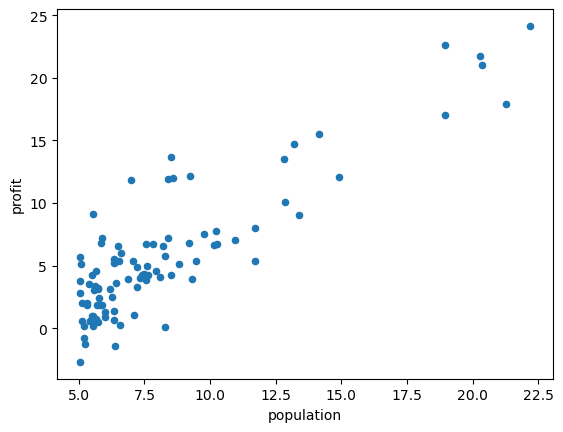

In [3]:
data = pandas.read_csv('Data/data.csv')
#print(data)

# Step 1 (simple analysis through visualizaton)
data.plot(kind='scatter', x='population', y='profit')
plot.show()

In [4]:
# Step 2
data = shuffle(data)
x = data['population'].to_numpy().reshape((-1,1))
y = data['profit'].to_numpy().reshape((-1,1))

# Step 3 (manual splitting, or we can use train_test_split instead)
x_train = x[0:80]
y_train = y[0:80]
x_test = x[80:]
y_test = y[80:]

In [5]:
# Step 4
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.23]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-4.19]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[36.73]


In [6]:
# Step 5
y_pred = model.predict(x_test)
print('Coefficients: \n', model.coef_, " ", model.intercept_)
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred))

Coefficients: 
 [[1.22703285]]   [-4.19202923]
Mean squared error: 3.66


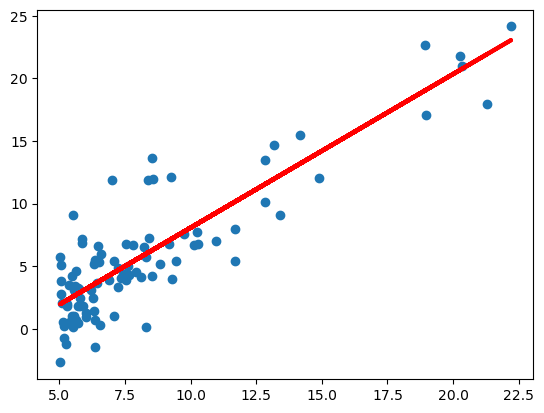

In [7]:
plot.scatter(x, y)
#plot.plot(x_test, y_pred, color='red', linewidth=3)
plot.plot(x, model.predict(x), color='red', linewidth=3)
plot.show()

In [8]:
# Step 6
new_pop_data = pandas.read_csv("Data/new_data.csv", names=['city','population'])
new_data = new_pop_data['population'].to_numpy().reshape(-1,1)
predictions = model.predict(new_data)

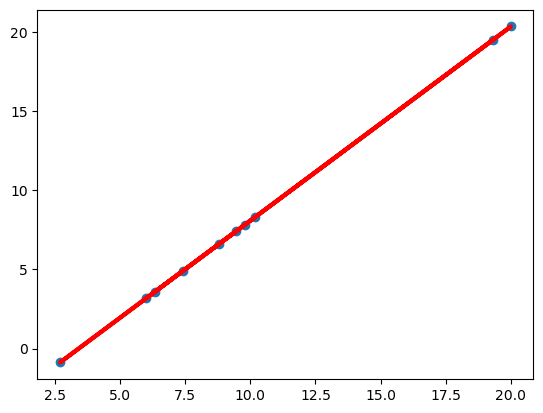

In [9]:
plot.scatter(new_pop_data['population'], predictions)
plot.plot(new_pop_data['population'], predictions, color='red', linewidth=3)

In [10]:
predictions

array([[ 7.40343124],
       [ 6.60585988],
       [-0.87904053],
       [20.34862785],
       [ 8.31143555],
       [ 4.88801389],
       [ 3.17016789],
       [ 3.59962939],
       [ 7.83289274],
       [19.48970485]])

In [11]:
def rmse(labels, predictions):
    m = len(labels)
    differences = np.subtract(labels.flatten(), predictions.flatten())
    return 1.0/m * (np.dot(differences, differences))

In [12]:
rmse(y,model.predict(x))

np.float64(6.938728010936444)